In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [ ]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
df["Class"].value_counts()
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

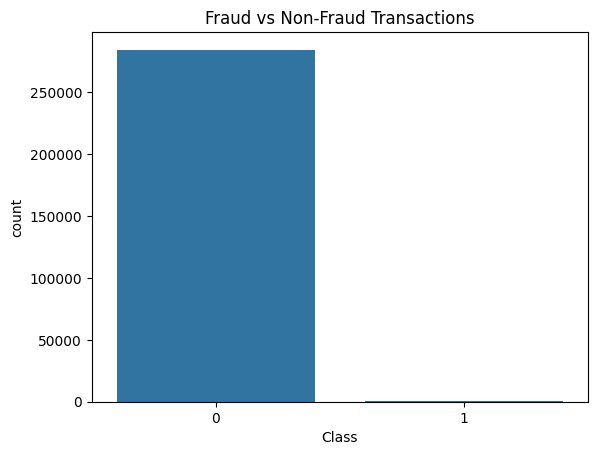

(284807, 30)
(284807,)
(227845, 30)
(56962, 30)
(454902, 30)
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train["Amount"] = scaler.fit_transform(
    X_train[["Amount"]]
)

X_test["Amount"] = scaler.transform(
    X_test[["Amount"]]
)

X_train["Time"] = scaler.fit_transform(
    X_train[["Time"]]
)

X_test["Time"] = scaler.transform(
    X_test[["Time"]]
)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_resampled.shape)
print(y_train_resampled.value_counts())

processed_train = X_train_resampled.copy()
processed_train["Class"] = y_train_resampled

processed_train.to_csv(
    "../data/processed/train_processed.csv",
    index=False
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_resampled, y_train_resampled)

y_pred = rf.predict(X_test)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56849    15]
 [   16    82]]
ROC-AUC: 0.9731024901519414


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

[[56809    55]
 [   13    85]]
ROC-AUC: 0.9768807494860635


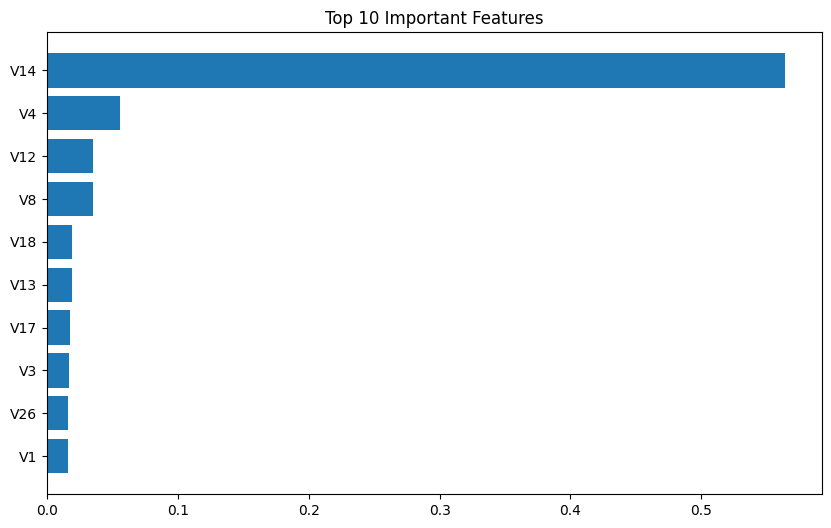

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(
    y_test,
    y_pred_xgb
))

print(confusion_matrix(
    y_test,
    y_pred_xgb
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_xgb
    )
)

import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_

indices = importance.argsort()[-10:]

plt.figure(figsize=(10,6))

plt.barh(
    X_train.columns[indices],
    importance[indices]
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "../models/fraud_detection_model.pkl"
)

import os

os.path.exists(
    "../models/fraud_detection_model.pkl"
)

True

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

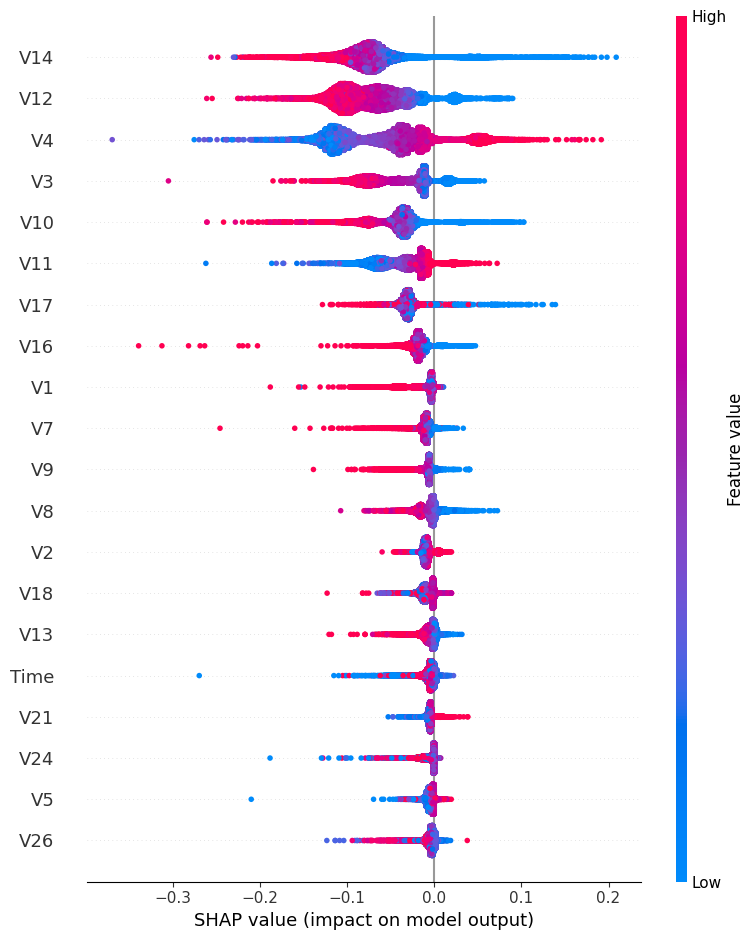

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": np.abs(
        shap_values[:, :, 1]   # Fraud class
    ).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
14     V14    0.079087
12     V12    0.073851
4       V4    0.067517
3       V3    0.045596
10     V10    0.044585
11     V11    0.036636
17     V17    0.031329
16     V16    0.018857
1       V1    0.011388
7       V7    0.010075


In [ ]:
top_features = feature_importance.head(10)

print(top_features)

   Feature  Importance
14     V14    0.079087
12     V12    0.073851
4       V4    0.067517
3       V3    0.045596
10     V10    0.044585
11     V11    0.036636
17     V17    0.031329
16     V16    0.018857
1       V1    0.011388
7       V7    0.010075


In [ ]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

In [ ]:
loaded_model = joblib.load(
    "../models/random_forest_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [1]:
import os

print(os.getcwd())

c:\Users\Diya\OneDrive\Desktop\ML PROJECTS\Fraud-Detection-System\notebooks


In [2]:
import os

print(os.path.exists("../models/random_forest_model.pkl"))

True


In [3]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/creditcard.csv"
)

In [4]:
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


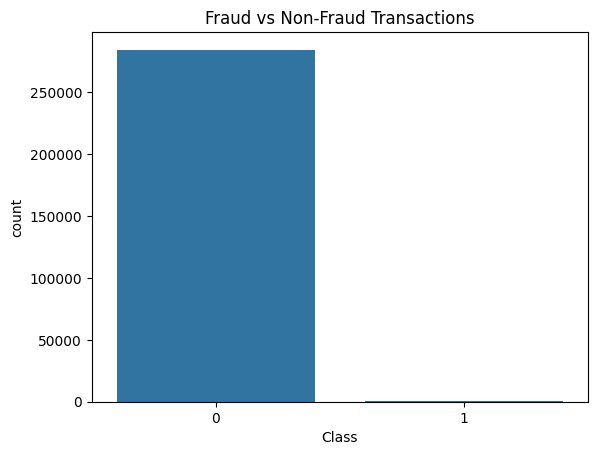

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Class",
    data=df
)

plt.title(
    "Fraud vs Non-Fraud Transactions"
)

plt.show()

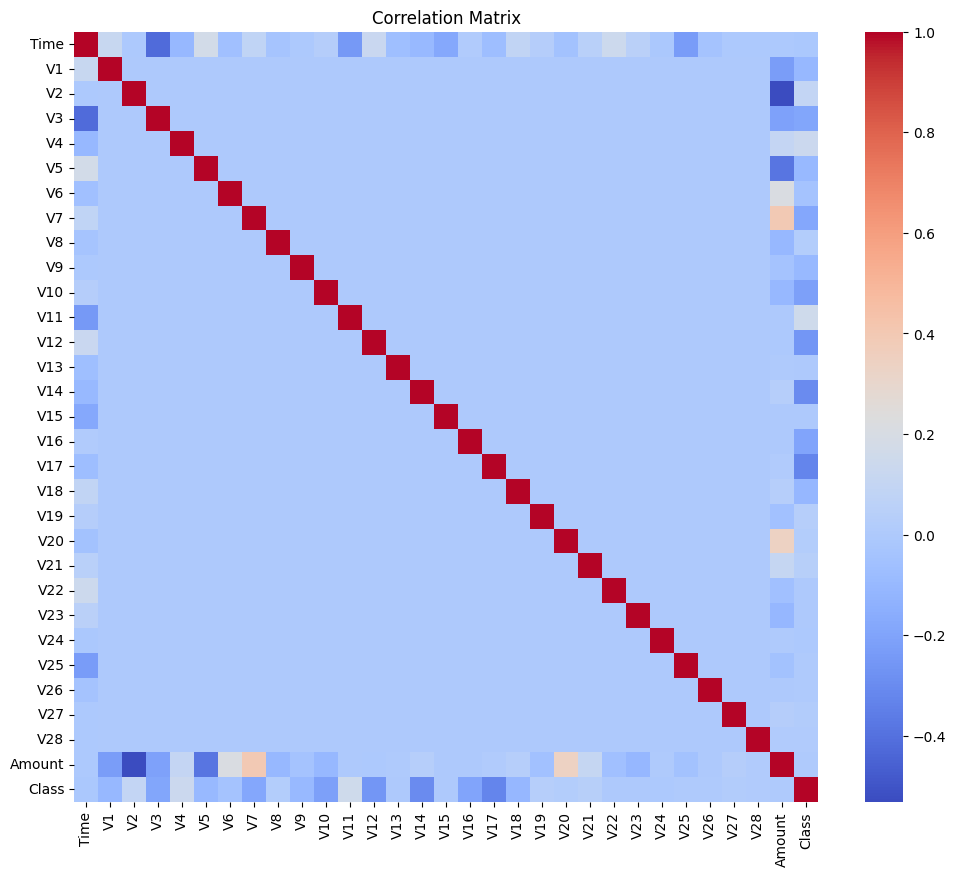

In [6]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [8]:
%whos

Variable    Type         Data/Info
----------------------------------
df          DataFrame    Shape: (284807, 31)
pd          module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt         module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
roc_curve   function     <function roc_curve at 0x000002C7906D77E0>
sns         module       <module 'seaborn' from 'c<...>s\\seaborn\\__init__.py'>


In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_resampled,
    y_train_resampled
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [13]:
from sklearn.metrics import roc_auc_score

y_probs = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_probs
)

print(roc_auc)

0.9644232605112952


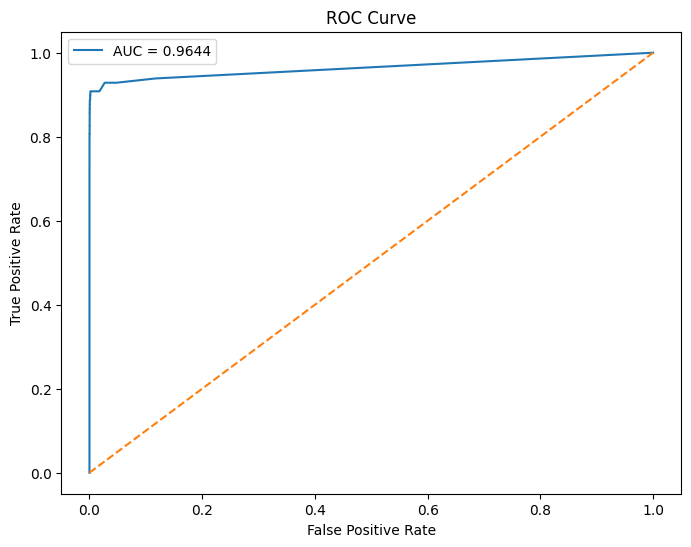

In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [15]:
print(rf)
print(X_test.shape)

RandomForestClassifier(n_jobs=-1, random_state=42)
(56962, 30)


In [16]:
from xgboost import XGBClassifier

In [17]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_resampled,
    y_train_resampled
)

y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [18]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

print(
    roc_auc_score(
        y_test,
        y_prob_xgb
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

0.9831145633548861


In [19]:
import joblib

joblib.dump(
    xgb,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

In [20]:
import os

print(
    os.path.exists(
        "../models/xgboost_model.pkl"
    )
)

True


In [21]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.702731
4,V4,0.056232
12,V12,0.030155
17,V17,0.020600
3,V3,0.015473
1,V1,0.013341
8,V8,0.013259
13,V13,0.012075
10,V10,0.009359
7,V7,0.009217


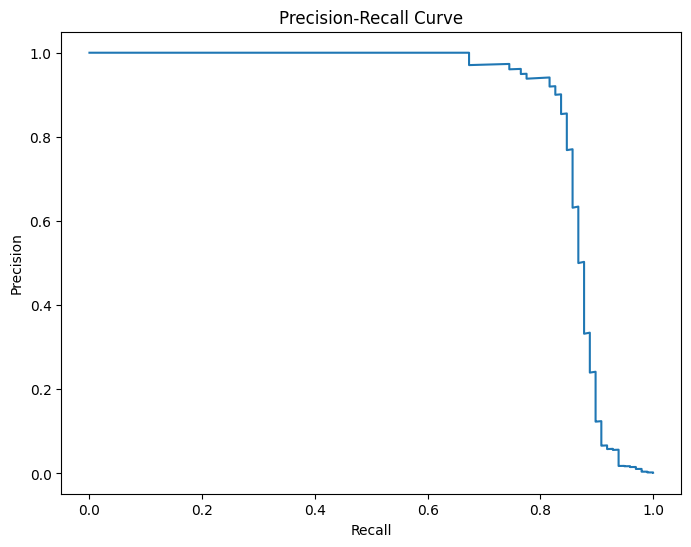

In [22]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [23]:
feature_importance.head(10)

,Feature,Importance
14,V14,0.702731
4,V4,0.056232
12,V12,0.030155
17,V17,0.020600
3,V3,0.015473
1,V1,0.013341
8,V8,0.013259
13,V13,0.012075
10,V10,0.009359
7,V7,0.009217


In [24]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

import os

print(
    os.path.exists(
        "../models/xgboost_model.pkl"
    )
)

NameError: name 'xgb_model' is not defined

In [25]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SMOTE                    ABCMeta                   <class 'imblearn.over_sam<...>pling._smote.base.SMOTE'>
X                        DataFrame                 Shape: (284807, 30)
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   DataFrame                 Shape: (56962, 30)
X_train                  DataFrame                 Shape: (227845, 30)
X_train_resampled        DataFrame                 Shape: (454902, 30)
classification_report    function                  <function classification_<...>rt at 0x000002C7906D44A0>
df                       DataFrame                 Shape: (284807, 31)
feature_importance       DataFrame                 Shape: (30, 2)
fpr                      ndarray              

In [26]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6
)

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [27]:
joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

In [28]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SMOTE                    ABCMeta                   <class 'imblearn.over_sam<...>pling._smote.base.SMOTE'>
X                        DataFrame                 Shape: (284807, 30)
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   DataFrame                 Shape: (56962, 30)
X_train                  DataFrame                 Shape: (227845, 30)
X_train_resampled        DataFrame                 Shape: (454902, 30)
classification_report    function                  <function classification_<...>rt at 0x000002C7906D44A0>
df                       DataFrame                 Shape: (284807, 31)
feature_importance       DataFrame                 Shape: (30, 2)
fpr                      ndarray              

In [29]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1
)

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SMOTE                    ABCMeta                   <class 'imblearn.over_sam<...>pling._smote.base.SMOTE'>
X                        DataFrame                 Shape: (284807, 30)
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   DataFrame                 Shape: (56962, 30)
X_train                  DataFrame                 Shape: (227845, 30)
X_train_resampled        DataFrame                 Shape: (454902, 30)
classification_report    function                  <function classification_<...>rt at 0x000002C7906D44A0>
df                       DataFrame                 Shape: (284807, 31)
feature_importance       DataFrame                 Shape: (30, 2)
fpr                      ndarray              

In [31]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1
)

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Training Complete!")

Training Complete!


In [32]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [33]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SMOTE                    ABCMeta                   <class 'imblearn.over_sam<...>pling._smote.base.SMOTE'>
X                        DataFrame                 Shape: (284807, 30)
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   DataFrame                 Shape: (56962, 30)
X_train                  DataFrame                 Shape: (227845, 30)
X_train_resampled        DataFrame                 Shape: (454902, 30)
classification_report    function                  <function classification_<...>rt at 0x000002C7906D44A0>
df                       DataFrame                 Shape: (284807, 31)
feature_importance       DataFrame                 Shape: (30, 2)
fpr                      ndarray              

In [34]:
from xgboost import XGBClassifier

print("Step 1")

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1
)

print("Step 2")

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Step 3")

Step 1
Step 2
Step 3


In [35]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [36]:
print(X_train_resampled.shape)
print(y_train_resampled.shape)

(454902, 30)
(454902,)


In [37]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SMOTE                    ABCMeta                   <class 'imblearn.over_sam<...>pling._smote.base.SMOTE'>
X                        DataFrame                 Shape: (284807, 30)
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   DataFrame                 Shape: (56962, 30)
X_train                  DataFrame                 Shape: (227845, 30)
X_train_resampled        DataFrame                 Shape: (454902, 30)
classification_report    function                  <function classification_<...>rt at 0x000002C7906D44A0>
df                       DataFrame                 Shape: (284807, 31)
feature_importance       DataFrame                 Shape: (30, 2)
fpr                      ndarray              

In [38]:
from xgboost import XGBClassifier
import joblib
import os

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

print("Saved:", os.path.exists("../models/xgboost_model.pkl"))

Saved: True


In [39]:
import os

print(os.listdir("../models"))

['fraud_detection_model.pkl', 'random_forest_model.pkl', 'xgboost_model.pkl']


In [40]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SMOTE                    ABCMeta                   <class 'imblearn.over_sam<...>pling._smote.base.SMOTE'>
X                        DataFrame                 Shape: (284807, 30)
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>
X_test                   DataFrame                 Shape: (56962, 30)
X_train                  DataFrame                 Shape: (227845, 30)
X_train_resampled        DataFrame                 Shape: (454902, 30)
classification_report    function                  <function classification_<...>rt at 0x000002C7906D44A0>
df                       DataFrame                 Shape: (284807, 31)
feature_importance       DataFrame                 Shape: (30, 2)
fpr                      ndarray              

In [41]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

In [42]:
import os

print(
    os.path.exists(
        "../models/xgboost_model.pkl"
    )
)

True


In [43]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
14,V14,0.702731
4,V4,0.056232
12,V12,0.030155
17,V17,0.020600
3,V3,0.015473
1,V1,0.013341
8,V8,0.013259
13,V13,0.012075
10,V10,0.009359
7,V7,0.009217


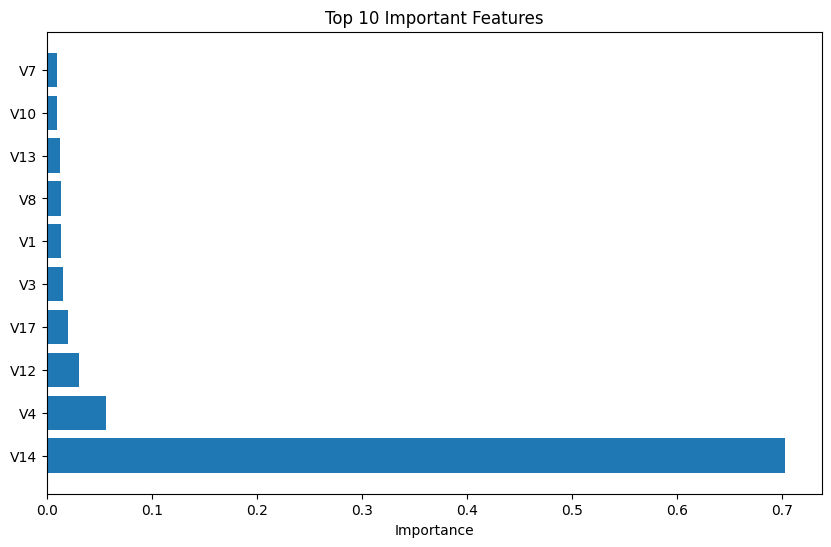

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title(
    "Top 10 Important Features"
)

plt.xlabel("Importance")

plt.show()

In [45]:
plt.savefig(
    "../images/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

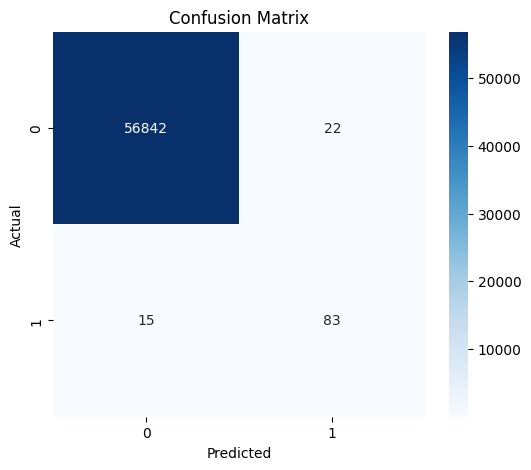

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [47]:
plt.savefig(
    "../images/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [48]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

sample = df.drop("Class", axis=1).head(20)

sample.to_csv(
    "../data/raw/sample_transactions.csv",
    index=False
)

print(sample.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27 